In [1]:
import os
import json
import warnings
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import pyodbc  

import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import optuna
import shap

from optuna import trial
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, accuracy_score, precision_score, recall_score,
  f1_score, roc_auc_score,  average_precision_score,  confusion_matrix,  roc_curve, auc,
   ConfusionMatrixDisplay,PrecisionRecallDisplay, RocCurveDisplay)
  
from preprocessors import GroupMedianImputer, CategoricalCaster

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"  
    "DATABASE=NovaBank_CreditRisk;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

query = "SELECT * FROM dbo.vw_credit_risk_base"
df_raw = pd.read_sql(query, conn)

df_sm = df_raw.copy()

In [11]:
#Target columns
target = "loan_status"

#numeric
numeric_cols = [
    "person_age",
    "person_income",
    "other_debt",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_term_months",
    "loan_percent_income",
    "debt_to_income_ratio",
    "loan_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "past_delinquencies"
]

categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "employment_type",
    "education_level",
    "cb_person_default_on_file"
]

In [12]:
X = df_sm[numeric_cols + categorical_cols]
y = df_sm[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Testing set : {X_test.shape}")

Training set : (26064, 19)
Testing set : (6517, 19)


In [13]:
#Cap outliers
X_train["person_age"] = X_train["person_age"].clip(upper=80)
X_test["person_age"]  = X_test["person_age"].clip(upper=80)

X_train["person_emp_length"] = X_train["person_emp_length"].clip(upper=60)
X_test["person_emp_length"]  = X_test["person_emp_length"].clip(upper=60)

X_train["debt_to_income_ratio"] = X_train["debt_to_income_ratio"].clip(upper=1.0)
X_test["debt_to_income_ratio"]  = X_test["debt_to_income_ratio"].clip(upper=1.0)

print(X_train[["person_age", "person_emp_length", "debt_to_income_ratio"]].max())


#Missing Flags
X_train["emp_length_missing"] = X_train["person_emp_length"].isna().astype(int)
X_test["emp_length_missing"]  = X_test["person_emp_length"].isna().astype(int)

X_train["loan_int_rate_missing"] = X_train["loan_int_rate"].isna().astype(int)
X_test["loan_int_rate_missing"]  = X_test["loan_int_rate"].isna().astype(int)

print(X_train[["emp_length_missing", "loan_int_rate_missing"]].sum())
print(X_test[["emp_length_missing", "loan_int_rate_missing"]].sum())


#has prior default
X_train["has_prior_default"] = (  X_train["cb_person_default_on_file"]
    .map({"Y": 1, "N": 0}))

X_test["has_prior_default"] = ( X_test["cb_person_default_on_file"]
    .map({"Y": 1, "N": 0}))


#high loan burden flag
X_train["high_loan_burden_flag"] = (
    (X_train["loan_to_income_ratio"] > 0.30) | (X_train["debt_to_income_ratio"] > 0.40) ).astype(int)

X_test["high_loan_burden_flag"] = (
    (X_test["loan_to_income_ratio"] > 0.30) | (X_test["debt_to_income_ratio"] > 0.40) ).astype(int)


#Log1p
log1p_features = [
    "person_income",
    "other_debt",
]
for col in log1p_features:
      X_train[f"{col}_log"] = np.log1p(X_train[col])
      X_test[f"{col}_log"]  = np.log1p(X_test[col])


person_age              80.0
person_emp_length       60.0
debt_to_income_ratio     1.0
dtype: float64
emp_length_missing        738
loan_int_rate_missing    2501
dtype: int64
emp_length_missing       157
loan_int_rate_missing    615
dtype: int64


In [14]:
#set feature
numeric_LGBM = [
    "person_age",
    "person_income_log",
    "other_debt_log",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_term_months",
    "loan_percent_income",
    "debt_to_income_ratio",
    "loan_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "has_prior_default",
    "past_delinquencies",
    "emp_length_missing",
    "loan_int_rate_missing",
    "high_loan_burden_flag"
]

categorical_LGBM = [
    "person_home_ownership",
    "loan_intent",
    "employment_type",
    "education_level"
]

In [ ]:
X_train_LGBM = X_train[numeric_LGBM + categorical_LGBM].copy()
X_test_LGBM = X_test[numeric_LGBM + categorical_LGBM].copy()

In [16]:
from preprocessors import GroupMedianImputer

# Điền giá trị thiếu dựa trên nhóm
imputer = GroupMedianImputer()
X_train_imputed = imputer.fit_transform(X_train_LGBM)
X_test_imputed = imputer.transform(X_test_LGBM)


In [ ]:
from imblearn.over_sampling import SMOTENC

# Xác định các cột 
categorical_cols = ["person_home_ownership", "loan_intent", "employment_type", "education_level"]
categorical_indices = [X_train_imputed.columns.get_loc(col) for col in categorical_cols]

#  Khởi tạo chạy SMOTE NC 
smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train_imputed, y_train)


In [24]:
import pandas as pd

print("ban đầu")
print(y_train.value_counts())

print("\n sau khi smote ")
print(pd.Series(y_train_resampled).value_counts())


ban đầu
loan_status
0    20378
1     5686
Name: count, dtype: int64

 sau khi smote 
loan_status
0    20378
1    20378
Name: count, dtype: int64


In [ ]:
#  Định nghĩa Pipeline 
LGBM_pipeline = Pipeline([
    ("group_imputer", GroupMedianImputer()),
    ("caster",  CategoricalCaster(cols=categorical_LGBM)),
    ("model", LGBMClassifier(   
        objective = "binary",                     # bài toán phân loại nhị phân
        boosting_type = "gbdt",                   # thuật toán boosting decision tree
        n_estimators = 100,                       # số lượng cây trong mô hình
        random_state = 42,                        # random state để tái lập kết quả
        n_jobs = -1,                              # số lượng CPU sử dụng
        verbose = -1,                             # tắt log 
    ))
])

#  Huấn luyện mô hình 
lgbm_model = LGBM_pipeline.fit(X_train_resampled, y_train_resampled)

# Set ngưỡng dự đoán
threshold = 0.5

# Dự đoán trên tập Train 
y_train_proba_lgbm = lgbm_model.predict_proba(X_train_resampled)[:, 1]
y_test_proba_lgbm  = lgbm_model.predict_proba(X_test_LGBM)[:, 1]

# Dự đoán nhãn dựa trên ngưỡng
y_train_pred_lgbm = (y_train_proba_lgbm >= threshold).astype(int)
y_test_pred_lgbm  = (y_test_proba_lgbm >= threshold).astype(int)

# Classification Report
print("Classification Report — TRAIN SET (Resampled)")
print(classification_report(y_train_resampled, y_train_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_train_resampled, y_train_proba_lgbm):.4f}")
print(f"PR-AUC: {average_precision_score(y_train_resampled, y_train_proba_lgbm):.4f}")

print("\nClassification Report — TEST SET (Original)")
print(classification_report(y_test, y_test_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba_lgbm):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_test_proba_lgbm):.4f}")



Classification Report — TRAIN SET (Resampled)
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     20378
           1       0.98      0.90      0.94     20378

    accuracy                           0.94     40756
   macro avg       0.94      0.94      0.94     40756
weighted avg       0.94      0.94      0.94     40756

ROC-AUC: 0.9828
PR-AUC: 0.9862

Classification Report — TEST SET (Original)
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      5095
           1       0.88      0.71      0.79      1422

    accuracy                           0.92      6517
   macro avg       0.90      0.84      0.87      6517
weighted avg       0.91      0.92      0.91      6517

ROC-AUC: 0.9229
PR-AUC: 0.8630


In [25]:
SEED = 42
N_FOLDS = 5                 # số lượng fold trong cross-validation
N_TRIALS = 50               # số lượng thử nghiệm tối ưu hóa 

# Khởi tạo kfold phân tầng trên tập dữ liệu đã cân bằng
kf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

# Đảm bảo dữ liệu sau SMOTE ở dạng DataFrame và Series để truy cập .iloc không bị lỗi
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train_LGBM.columns)
y_train_resampled = pd.Series(y_train_resampled)

def objective(trial):
    params = {
        "objective": "binary",                  # nhị phân
        "boosting_type": "gbdt",                # decision tree
        "random_state": SEED,
        "n_jobs": -1,                           # sử dụng tất cả CPU
        "verbosity": -1,                        # tắt log
        "metric": "average_precision",          # tối ưu hóa theo PR-AUC
        "n_estimators": 500,                    # số lượng cây 
        
        # BỎ scale_pos_weight vì dữ liệu sau SMOTE đã cân bằng 50/50
        # "scale_pos_weight": scale_pos_weight,   

        # Tham số cần tối ưu
        "max_depth": trial.suggest_int("max_depth", 3, 6),                              # độ sâu tối đa của cây
        "num_leaves": trial.suggest_int("num_leaves", 5, 60),                           # số lá của cây quyết định
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.04, log=True),    # tốc độ học
        "min_child_samples": trial.suggest_int("min_child_samples", 120, 400),          # số mẫu tối thiểu trong một node lá
        "min_split_gain": trial.suggest_float("min_split_gain", 0.05, 1.0),             # gain tối thiểu để phân chia node
        "reg_alpha": trial.suggest_float("reg_alpha", 0.001, 10.00, log=True),          # tham số phạt trị tuyệt đối l1
        "reg_lambda": trial.suggest_float("reg_lambda", 0.005, 20.00, log=True),        # tham số phạt bình phương trọng số l2
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 0.8),          # tỷ lệ cột trên mỗi cây
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 0.8)           # tỷ lệ số mẫu trên mỗi cây
    }

    pr_auc_scores = []

    # Đánh giá params trên 5 folds dựa trên tập dữ liệu đã chạy SMOTE (X_train_resampled, y_train_resampled)
    for fold, (train_idx, val_idx) in enumerate(
        kf.split(X_train_resampled, y_train_resampled), start=1):

        # Chia fold từ tập resampled đã được hiệu chuẩn SMOTE
        X_fold_train = X_train_resampled.iloc[train_idx].copy()
        X_fold_val = X_train_resampled.iloc[val_idx].copy()

        y_fold_train = y_train_resampled.iloc[train_idx]
        y_fold_val = y_train_resampled.iloc[val_idx]
    
        # Pipeline 
        pipeline = Pipeline([
            ("imputer", GroupMedianImputer()),
            ("caster",  CategoricalCaster(cols=categorical_LGBM)),
            ("model",   LGBMClassifier(**params))
        ])

        # Train lightgbm
        pipeline.fit(
            X_fold_train, y_fold_train,
            model__categorical_feature=categorical_LGBM,
            model__callbacks=[log_evaluation(0)])

        y_val_proba = pipeline.predict_proba(X_fold_val)[:, 1]
        fold_pr_auc = average_precision_score(y_fold_val, y_val_proba)
        pr_auc_scores.append(fold_pr_auc)

    return np.mean(pr_auc_scores)


In [26]:
import warnings
import optuna
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Tối ưu hóa tham số với Optuna
study = optuna.create_study(
    direction="maximize",  
    sampler=optuna.samplers.TPESampler(seed=SEED) 
)
study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("Best PR-AUC: ")
print(round(study.best_value, 4))
print("Best params: ")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best trial: 46. Best value: 0.980277: 100%|██████████| 50/50 [02:32<00:00,  3.06s/it]

Best PR-AUC: 
0.9803
Best params: 
max_depth: 6
num_leaves: 51
learning_rate: 0.03760831415444321
min_child_samples: 287
min_split_gain: 0.5428187846168354
reg_alpha: 0.001596566808154484
reg_lambda: 0.3892105077082066
feature_fraction: 0.7154572242562389
bagging_fraction: 0.7176112308140522


In [27]:
import pandas as pd
from imblearn.over_sampling import SMOTENC

best_params = study.best_params.copy()

# 1. Tách tập Train (LGBM) hiện tại ra làm 90% train_es và 10% val_es để làm early stopping
X_es_train, X_es_val, y_es_train, y_es_val = train_test_split(
    X_train_LGBM, y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

# 2. Điền giá trị khuyết thiếu trước (fit trên train_es, transform trên cả 2)
imputer = GroupMedianImputer()
X_es_train_imputed = imputer.fit_transform(X_es_train)
X_es_val_imputed = imputer.transform(X_es_val)

# 3. Chạy SMOTE-NC CHỈ trên tập train_es (Tập val_es giữ nguyên bản không SMOTE)
categorical_indices = [X_es_train_imputed.columns.get_loc(col) for col in categorical_LGBM]
smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=SEED)
X_es_train_resampled, y_es_train_resampled = smote_nc.fit_resample(X_es_train_imputed, y_es_train)

# Đảm bảo định dạng DataFrame/Series sau SMOTE
X_es_train_resampled = pd.DataFrame(X_es_train_resampled, columns=X_train_LGBM.columns)
y_es_train_resampled = pd.Series(y_es_train_resampled)

# 4. Ép kiểu dữ liệu CategoricalCaster trước khi fit
caster = CategoricalCaster(cols=categorical_LGBM)
X_es_train_p = caster.fit_transform(X_es_train_resampled)
X_es_val_p   = caster.transform(X_es_val_imputed)

# 5. Khởi tạo LGBMClassifier với bộ tham số tốt nhất từ Optuna
lgbm_es = LGBMClassifier(
    **best_params,
    objective = "binary",
    n_estimators = 1000,  
    random_state = SEED,
    n_jobs = -1,
    verbosity = -1
)

# 6. Fit mô hình (Train trên tập SMOTE, kiểm thử trên tập nguyên bản để tìm điểm dừng)
lgbm_es.fit(
    X_es_train_p,
    y_es_train_resampled,
    eval_set=[(X_es_val_p, y_es_val)],
    eval_metric="average_precision",
    categorical_feature=categorical_LGBM,
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            verbose=True
        ),
        log_evaluation(100)
    ])

best_n = lgbm_es.best_iteration_
print(f"Best iteration: {best_n}")


Training until validation scores don't improve for 100 rounds
[100]	valid_0's average_precision: 0.8181	valid_0's binary_logloss: 0.340754
[200]	valid_0's average_precision: 0.826343	valid_0's binary_logloss: 0.301075
[300]	valid_0's average_precision: 0.830713	valid_0's binary_logloss: 0.279186
[400]	valid_0's average_precision: 0.839275	valid_0's binary_logloss: 0.266477
[500]	valid_0's average_precision: 0.846194	valid_0's binary_logloss: 0.25784
[600]	valid_0's average_precision: 0.851111	valid_0's binary_logloss: 0.251619
[700]	valid_0's average_precision: 0.85406	valid_0's binary_logloss: 0.247567
[800]	valid_0's average_precision: 0.856748	valid_0's binary_logloss: 0.244361
Early stopping, best iteration is:
[791]	valid_0's average_precision: 0.856748	valid_0's binary_logloss: 0.244361
Best iteration: 791


In [28]:
# 1. Định nghĩa final pipeline (LOẠI BỎ scale_pos_weight)
lgbm_pipeline = Pipeline([
    ("imputer", GroupMedianImputer()),
    ("caster", CategoricalCaster(cols=categorical_LGBM)),
    ("model", LGBMClassifier(
        **best_params,
        objective = "binary",
        n_estimators = best_n,
        random_state  = SEED,
        n_jobs = -1,
        verbosity = -1
    ))
])

# 2. Huấn luyện trên toàn bộ tập dữ liệu đã cân bằng mẫu (resampled)
lgbm_pipeline.fit(
    X_train_resampled,
    y_train_resampled,
    model__categorical_feature=categorical_LGBM
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('caster', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cols,"['person_home_ownership', 'loan_intent', ...]"
,boosting_type,'gbdt'
,num_leaves,51
,max_depth,6
,learning_rate,0.03760831415444321
,n_estimators,791
,subsample_for_bin,200000


Classification Report — TRAIN SET (Resampled)
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     20378
           1       0.99      0.92      0.95     20378

    accuracy                           0.95     40756
   macro avg       0.96      0.95      0.95     40756
weighted avg       0.96      0.95      0.95     40756

ROC-AUC: 0.9889
PR-AUC: 0.9910

Classification Report — TEST SET (Original)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5095
           1       0.87      0.73      0.79      1422

    accuracy                           0.92      6517
   macro avg       0.90      0.85      0.87      6517
weighted avg       0.92      0.92      0.91      6517

ROC-AUC: 0.9293
PR-AUC: 0.8724


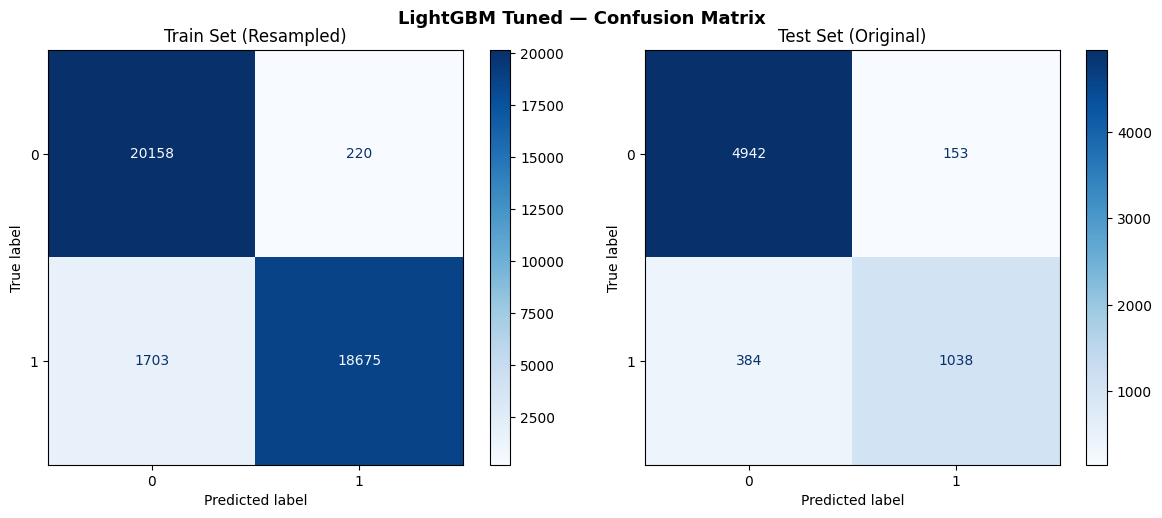

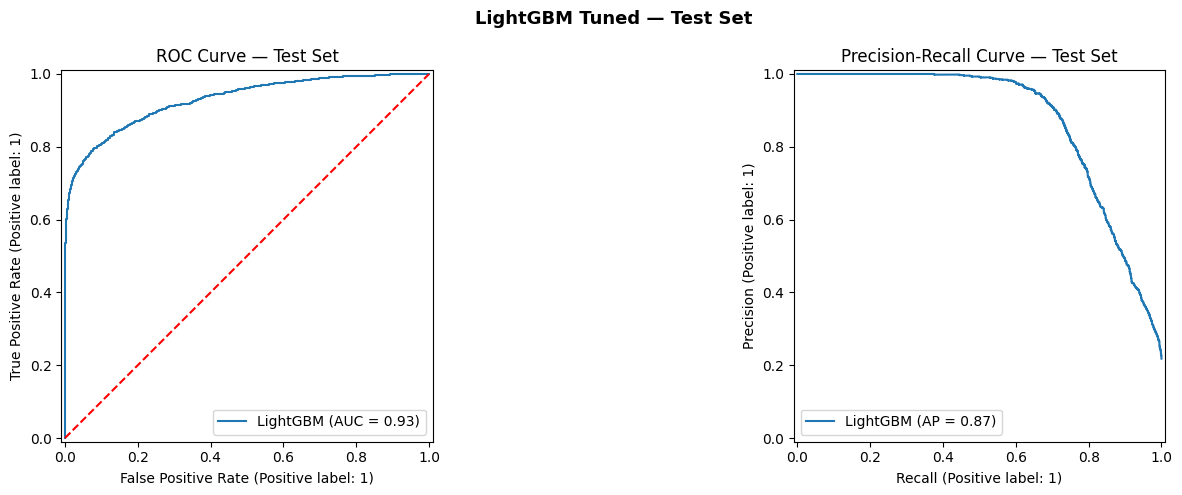

In [35]:
# set ngưỡng 
threshold = 0.5

# 1. Dự đoán xác suất về lớp 1
# Dự đoán trên tập Train đã cân bằng (resampled)
y_train_proba_tuned = lgbm_pipeline.predict_proba(X_train_resampled)[:, 1]
# Dự đoán trên tập Test gốc (X_test_LGBM)
y_test_proba_tuned = lgbm_pipeline.predict_proba(X_test_LGBM)[:, 1]

# 2. Dự đoán nhãn dựa trên ngưỡng
y_train_pred_tuned = (y_train_proba_tuned >= threshold).astype(int)
y_test_pred_tuned = (y_test_proba_tuned >= threshold).astype(int)

# Classification Report
print("Classification Report — TRAIN SET (Resampled)")
print(classification_report(y_train_resampled, y_train_pred_tuned,))
print(f"ROC-AUC: {roc_auc_score(y_train_resampled, y_train_proba_tuned):.4f}")
print(f"PR-AUC: {average_precision_score(y_train_resampled, y_train_proba_tuned):.4f}")

print("\nClassification Report — TEST SET (Original)")
print(classification_report(y_test, y_test_pred_tuned,))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba_tuned):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_test_proba_tuned):.4f}")

# Confusion Matrix 
matrix_train = confusion_matrix(y_train_resampled, y_train_pred_tuned, labels=[0, 1])
matrix_test = confusion_matrix(y_test, y_test_pred_tuned, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("LightGBM Tuned — Confusion Matrix", fontsize=13, fontweight="bold")

ConfusionMatrixDisplay(matrix_train, display_labels=["0", "1"]).plot(
    ax=axes[0], values_format="d", colorbar=True, cmap="Blues")
axes[0].set_title("Train Set (Resampled)")

ConfusionMatrixDisplay(matrix_test, display_labels=["0", "1"]).plot(
    ax=axes[1], values_format="d", colorbar=True, cmap="Blues")
axes[1].set_title("Test Set (Original)")

plt.tight_layout()
plt.show()

# ROC & PR Curves 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("LightGBM Tuned — Test Set", fontsize=13, fontweight="bold")

RocCurveDisplay.from_predictions(
    y_test, y_test_proba_tuned, name="LightGBM", ax=axes[0])
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--", )
axes[0].set_title("ROC Curve — Test Set")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba_tuned, name="LightGBM", ax=axes[1])
axes[1].set_title("Precision-Recall Curve — Test Set")

plt.tight_layout()
plt.show()


In [41]:
# Chạy lại bài test kiểm tra độ lệch PD với model SMOTE
# Dùng lgbm_pipeline và tập test X_test_LGBM
y_test_proba_smote = lgbm_pipeline.predict_proba(X_test_LGBM)[:, 1]

pd_trung_binh_smote = y_test_proba_smote.mean()
ty_le_thuc_te = y_test.mean()  # vẫn là 0.2182

print(f"PD trung bình (SMOTE): {pd_trung_binh_smote:.4f}")
print(f"Tỷ lệ thực tế: {ty_le_thuc_te:.4f}")
print(f"Độ lệch: {pd_trung_binh_smote - ty_le_thuc_te:.4f}")


PD trung bình (SMOTE): 0.2535
Tỷ lệ thực tế: 0.2182
Độ lệch: 0.0353
